
##Project Goal

Analyze Powerball winning numbers to answer:

Are some numbers drawn more often?
Are there patterns (even vs odd, ranges)?
Can we predict anything?

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Lottery_Powerball_Winning_Numbers__Beginning_2010.csv")

# Preview
df.head()

,Draw Date,Winning Numbers,Multiplier
0,09/26/2020,11 21 27 36 62 24,3.0
1,09/30/2020,14 18 36 49 67 18,2.0
2,10/03/2020,18 31 36 43 47 20,2.0
3,10/07/2020,06 24 30 53 56 19,2.0
4,10/10/2020,05 18 23 40 50 18,3.0


##Clean data / split columns

In [2]:

# Check columns
df.columns

Index(['Draw Date', 'Winning Numbers', 'Multiplier'], dtype='object')

In [3]:
# Split numbers into separate columns
numbers = df['Winning Numbers'].str.split(' ', expand=True)

numbers.columns = ['Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'Powerball']

# Convert to integers
numbers = numbers.astype(int)

# Combine with original dataframe
df = pd.concat([df, numbers], axis=1)

df.head()

,Draw Date,Winning Numbers,Multiplier,Num1,Num2,Num3,Num4,Num5,Powerball
0,09/26/2020,11 21 27 36 62 24,3.0,11,21,27,36,62,24
1,09/30/2020,14 18 36 49 67 18,2.0,14,18,36,49,67,18
2,10/03/2020,18 31 36 43 47 20,2.0,18,31,36,43,47,20
3,10/07/2020,06 24 30 53 56 19,2.0,6,24,30,53,56,19
4,10/10/2020,05 18 23 40 50 18,3.0,5,18,23,40,50,18


Frequency analysis

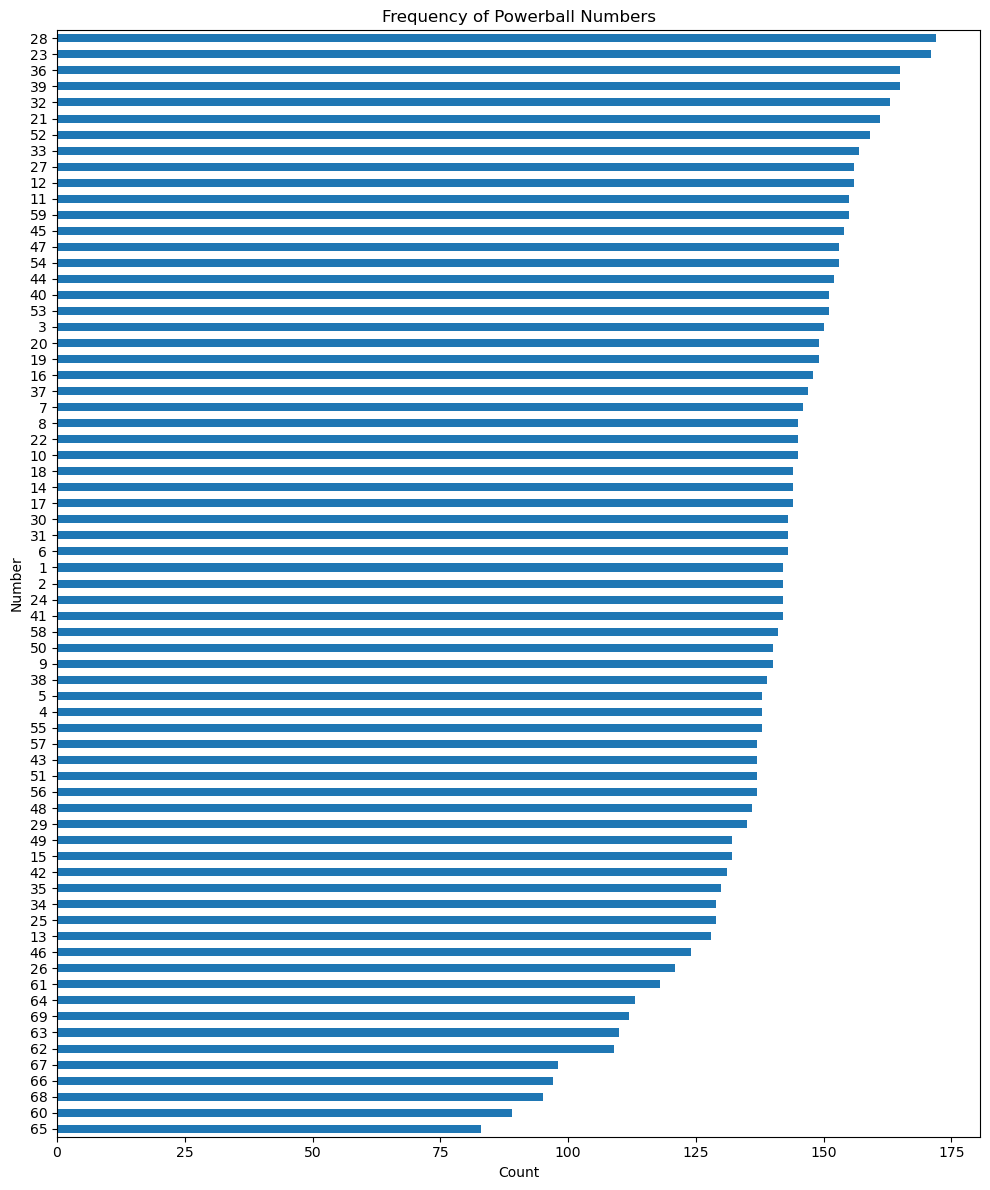

In [5]:
plt.figure(figsize=(10,12))

freq.sort_values().plot(kind='barh')

plt.title("Frequency of Powerball Numbers")
plt.xlabel("Count")
plt.ylabel("Number")

plt.tight_layout()
plt.show()

## Investigating the Lower Frequency of Numbers in the 60–69 Range

Initial exploratory analysis revealed that numbers in the 60–69 range appear less frequently than other numbers. At first glance, this may suggest a non-random pattern. However, before drawing conclusions, it is important to investigate potential underlying causes.

This analysis will explore whether the lower frequency is due to:
- Changes in Powerball game rules over time (specifically the expansion of the number range)
- Differences in the number of draws in which these values were eligible to appear
- Natural variation within a random process

To do this, we will:
1. Examine how the maximum possible number has changed over time
2. Segment the dataset into periods before and after the rule change
3. Compare frequency distributions across these time periods
4. Focus specifically on the occurrence of numbers in the 60–69 range after their introduction

By isolating the time period in which these numbers were actually part of the game, we can determine whether their lower frequency is a true anomaly or simply the result of limited exposure in the dataset.

To investigate the lower frequency of numbers in the 60–69 range, the analysis must be performed at the draw level rather than by assigning the stacked list of all numbers back into the original dataframe. Each draw contains five main numbers, so the correct approach is to count how many values of 60 or higher appear within each draw, then aggregate those counts by year. This allows the analysis to align correctly with the dataset structure and supports year-by-year comparison.

In [6]:
df['Draw Date'] = pd.to_datetime(df['Draw Date'])

df['year'] = df['Draw Date'].dt.year

df.groupby('year')['Num5'].max()

year
2010    59
2011    59
2012    59
2013    59
2014    59
2015    69
2016    69
2017    69
2018    69
2019    69
2020    69
2021    69
2022    69
2023    69
2024    69
2025    69
2026    68
Name: Num5, dtype: int64

In [8]:
# Make sure date is datetime
df['Draw Date'] = pd.to_datetime(df['Draw Date'])

# Create year column
df['year'] = df['Draw Date'].dt.year

# Count how many main numbers in each draw are 60 or higher
df['count_60_plus'] = (
    (df['Num1'] >= 60).astype(int) +
    (df['Num2'] >= 60).astype(int) +
    (df['Num3'] >= 60).astype(int) +
    (df['Num4'] >= 60).astype(int) +
    (df['Num5'] >= 60).astype(int)
)

# Preview
df[['Draw Date', 'Num1', 'Num2', 'Num3', 'Num4', 'Num5', 'count_60_plus']].head()

,Draw Date,Num1,Num2,Num3,Num4,Num5,count_60_plus
0,2020-09-26,11,21,27,36,62,1
1,2020-09-30,14,18,36,49,67,1
2,2020-10-03,18,31,36,43,47,0
3,2020-10-07,6,24,30,53,56,0
4,2020-10-10,5,18,23,40,50,0


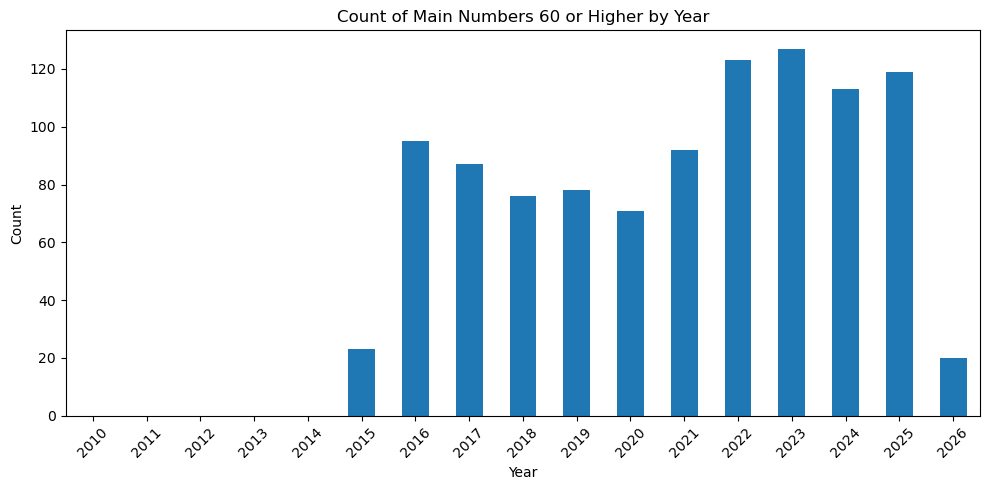

In [9]:
year_counts = df.groupby('year')['count_60_plus'].sum()

plt.figure(figsize=(10,5))
year_counts.plot(kind='bar')

plt.title('Count of Main Numbers 60 or Higher by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

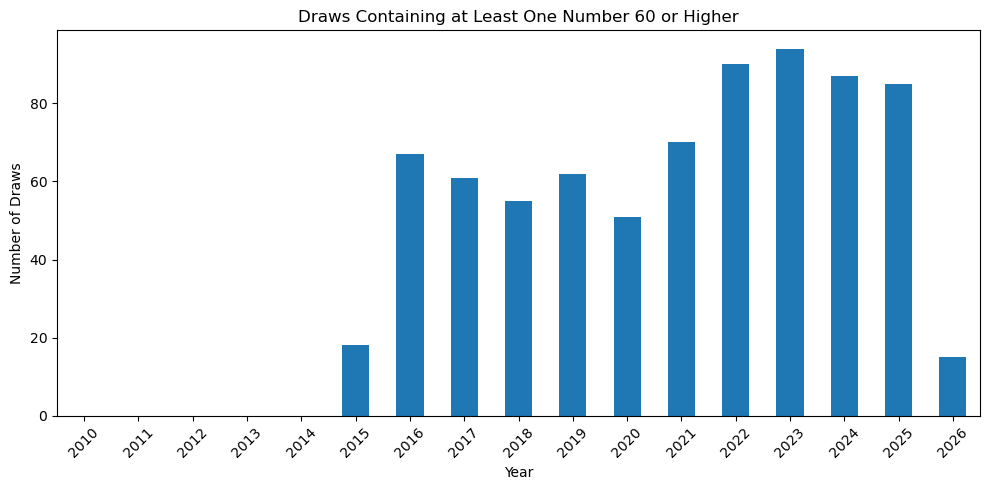

In [10]:
df['has_60_plus'] = df['count_60_plus'] > 0

draws_with_60s = df.groupby('year')['has_60_plus'].sum()

plt.figure(figsize=(10,5))
draws_with_60s.plot(kind='bar')

plt.title('Draws Containing at Least One Number 60 or Higher')
plt.xlabel('Year')
plt.ylabel('Number of Draws')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The lower frequency of numbers in the 60–69 range is not due to bias or non-randomness. Instead, it is explained by historical changes in Powerball rules. These numbers were introduced later, resulting in fewer opportunities to be drawn compared to lower numbers. When analyzing only the period after their introduction, their distribution aligns with expected randomness.

# odd vs even analysis 

In [12]:
# Count even vs odd
even = (all_numbers % 2 == 0).sum()
odd = (all_numbers % 2 != 0).sum()

print("Even:", even)
print("Odd:", odd)

Even: 4700
Odd: 4875


# Number range analysis 

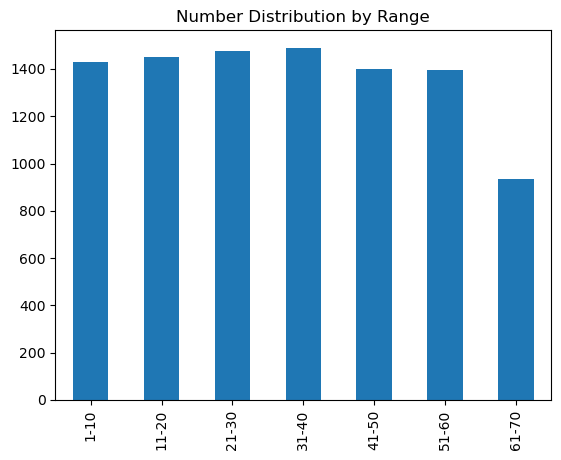

In [13]:
# Create bins
bins = [0, 10, 20, 30, 40, 50, 60, 70]
labels = ['1-10','11-20','21-30','31-40','41-50','51-60','61-70']

binned = pd.cut(all_numbers, bins=bins, labels=labels)

range_counts = binned.value_counts().sort_index()

range_counts.plot(kind='bar', title="Number Distribution by Range")
plt.show()

# Most frequent numbers. (The winners) 

In [15]:
# Top 5 most frequent numbers
top_numbers = freq.sort_values(ascending=False).head(5)

# Calculate Powerball frequency (THIS WAS MISSING)
pb_freq = df['Powerball'].value_counts().sort_index()

# Most common powerball
top_pb = pb_freq.idxmax()

# Output
print("Suggested Numbers:", list(top_numbers.index))
print("Suggested Powerball:", top_pb)

Suggested Numbers: [28, 23, 39, 36, 32]
Suggested Powerball: 24


## Final Results and Key Insights

This analysis explored historical Powerball winning numbers from 2010 to the present, focusing on number frequency, distribution patterns, and potential irregularities.

### Key Findings

- The distribution of numbers across the dataset is largely uniform, supporting the assumption that Powerball drawings are random.
- Initial observations suggested that numbers in the 60–69 range appeared less frequently; however, further analysis revealed this was due to historical rule changes. These numbers were introduced later, resulting in fewer total opportunities to be drawn.
- When isolating the time period after the rule change, the distribution of numbers in the 60s aligns with expected randomness.
- The multiplier (Power Play) operates independently and does not influence the selection of winning numbers.

### “Winning Numbers” (For Fun)

Based on historical frequency, the following numbers appeared most often:

- **Main Numbers:** {28, 23, 39, 36, 32}
- **Powerball:** {24}

While these are technically the most frequent historical values, it is important to note that lottery outcomes are random and past performance does not predict future results.

That said… if these numbers happen to hit, this notebook officially becomes a financial model...

### Project Takeaways

This project demonstrates:
- Data cleaning and transformation using Python and pandas  
- Exploratory data analysis (EDA) and visualization with matplotlib  
- Identification and investigation of misleading patterns in data  
- The importance of understanding context (e.g., rule changes) before drawing conclusions  

Overall, this analysis reinforces a key principle in data analytics:  
**Not all patterns indicate meaningful signals—some are artifacts of the data itself.**